In [1]:
pip install miditok


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.0/159.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 13.9 MB/s eta 0:00:00


In [1]:
pip install torch

In [3]:
pip install music21

In [4]:
pip install librosa pydub midi2audio IPython


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 14.6 MB/s eta 0:00:00


In [5]:
import gc

In [5]:
import os
os.environ["XLA_MODEL_PARALLEL"] = "1"

In [5]:
import torch

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
print(device)

cuda


In [8]:
from miditok import REMI, TokenizerConfig
from miditok.utils import split_files_for_training
from miditok.pytorch_data import DatasetMIDI, DataCollator
from torch.utils.data import DataLoader
from pathlib import Path

from miditok import REMI
tokenizer = REMI(params="/content/MIDI-LSTM-and-transformer-decoder/trained_tokenizer/tokenizer_final.json")


/usr/local/lib/python3.12/dist-packages/miditok/tokenizations/remi.py:88: UserWarning: Attribute controls are not compatible with 'config.one_token_stream_for_programs' and multi-vocabulary tokenizers. Disabling them from the config.
  super().__init__(tokenizer_config, params)


In [2]:
from google.colab import drive
drive.mount("/content/drive",force_remount=True)

Mounted at /content/drive


In [10]:
tokenizer.vocab_size


5000

In [11]:
import zipfile
import os

def extract_datasets(zip_path,extract_path):
  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
      erro = zip_ref.testzip()
      return zip_ref.extractall(extract_path)

In [12]:
training_unziped = extract_datasets("/content/MIDI-LSTM-and-transformer-decoder/features/dataset_training.zip","/content/dataset_training")

test_unziped = extract_datasets("/content/MIDI-LSTM-and-transformer-decoder/features/dataset_test.zip","/content/dataset_test")

validation_unziped = extract_datasets("/content/MIDI-LSTM-and-transformer-decoder/features/dataset_validation.zip","/content/dataset_validation")


In [13]:
training_path = list(Path("/content/dataset_training").glob("**/*.mid"))
validation_path = list(Path("/content/dataset_validation").glob("**/*.mid"))
test_path = list(Path("/content/dataset_test").glob("**/*.mid"))


In [14]:
print(len(training_path))
print(len(validation_path))
print(len(test_path))

15175
5951
2678


In [15]:
dataset_chunks_dir = Path("/content/training_chunked")

In [ ]:
max_seq_len = 512
batch_size = 128
hidden_dim = 2048
epochs = 41
embed_dim = 512
num_layers = 2
name_model = "pesos_lstm.pt"
version=8
complete_path = f"/content/MIDI-LSTM-and-transformer-decoder/training/tokenizer_novo/{version}/"

In [17]:
# Split MIDIs into smaller chunks for training
split_files_for_training(
    files_paths=training_path,
    tokenizer=tokenizer,
    save_dir=dataset_chunks_dir,
    max_seq_len=max_seq_len,
)
print(split_files_for_training) #512, 1024, or 2048 tokens

Splitting music files (/content/training_chunked): 100%|██████████| 15175/15175 [00:46<00:00, 323.80it/s]

<function split_files_for_training at 0x7aff5c20e700>


In [18]:
# Split MIDIs into smaller chunks for training
split_files_for_training(
    files_paths=training_path,
    tokenizer=tokenizer,
    save_dir=dataset_chunks_dir,
    max_seq_len=max_seq_len,
)
print(split_files_for_training) #512, 1024, or 2048 tokens

<function split_files_for_training at 0x7aff5c20e700>


In [19]:
dataset_training = DatasetMIDI(
    files_paths=list(dataset_chunks_dir.glob("**/*.mid")),
    tokenizer=tokenizer,
    max_seq_len=max_seq_len,
    bos_token_id=tokenizer["BOS_None"],
    eos_token_id=tokenizer["EOS_None"],
)
print(dataset_training)

136504 files.


In [20]:
dataset_validation = DatasetMIDI(
    files_paths=validation_path,
    tokenizer=tokenizer,
    max_seq_len=max_seq_len,
    bos_token_id=tokenizer["BOS_None"],
    eos_token_id=tokenizer["EOS_None"],
)
print(dataset_validation)

5951 files.


In [23]:
dataset_test = DatasetMIDI(
    files_paths=test_path,
    tokenizer=tokenizer,
    max_seq_len=max_seq_len,
    bos_token_id=tokenizer["BOS_None"],
    eos_token_id=tokenizer["EOS_None"],
)
print(dataset_test)

2678 files.


In [21]:
collator = DataCollator(pad_token_id=tokenizer.pad_token_id, copy_inputs_as_labels=True, shift_labels=True, labels_pad_idx=-100)


In [24]:
dataloader_validation = DataLoader(dataset_validation, batch_size=batch_size,num_workers=0, persistent_workers=False, collate_fn=collator,drop_last=True)

dataloader_test = DataLoader(dataset_test, batch_size=60, collate_fn=collator)

In [25]:
import random

def generate_sample_input_predict(dataloader_test):
  valor=random.randint(1, len(dataloader_test))
  counter = 1
  for batch in dataloader_test:
    if counter == valor:
      return batch["input_ids"]
    counter=counter+1

In [26]:
import torch
import torch.nn as nn

class MusicGeneratorLSTM(nn.Module):
    def __init__(self, vocab_size,embed_dim,hidden_dim,num_layers):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(vocab_size,embed_dim)
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True,dropout=0.2)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        if hidden is None:
            batch_size = x.size(0)
            device = x.device
            hidden = (
                torch.zeros(self.num_layers, batch_size, self.hidden_dim, device=device),
                torch.zeros(self.num_layers, batch_size, self.hidden_dim, device=device)
            )

        x = self.embedding(x)
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out)
        return out, hidden

In [73]:
from pathlib import Path

def converte_output_to_midi(lstm_output, name):
  os.makedirs(name.split("music")[0], exist_ok=True)
  os.makedirs(pasta_salvamento, exist_ok=True)
  lstm_output.dump_midi(Path(f"{name}.mid"))


In [28]:
from music21 import converter

def tonal_estimator(music):
  score = converter.parse(music)
  key = score.analyze("key")

  print(key)
  print(f"Tônica: {key.tonic.name} e modo: {key.mode}")
  print(f"Consistência tonal: {key.correlationCoefficient}")
  print(f"Melhor tonalidade: {key.tonalCertainty()}")

In [29]:
from collections import defaultdict
import matplotlib.pyplot as plt
import librosa

def counter_notes(music):
  counter_bar = defaultdict(int)
  counter_pitch = defaultdict(int)
  counter_velocity = defaultdict(int)

  for token in music:
    if "bar" in token.lower():
      counter_bar["bar"] += 1
    #altura das notas
    if "velocity" in token.lower():
      velocity = int(token.split("_")[1])
      counter_velocity[velocity] += 1
    # Quando encontra um Pitch (Note On)
    elif "pitch" in token.lower():
        pitch_val = int(token.split("_")[1])
        pitch_note = librosa.midi_to_note(pitch_val)
        counter_pitch[pitch_note] += 1

  plt.figure(figsize=(20, 10))
  majors_pitch = sorted(counter_pitch.items(), key=lambda x: x[1], reverse=True)
  majors_velocity = sorted(counter_velocity.items(), key=lambda x: x[1], reverse=True)

  x_pitch,y_pitch = zip(*majors_pitch)
  plt.bar(x_pitch,y_pitch, color='skyblue')

  plt.title('Notas mais tocadas')
  plt.xlabel('Notas')
  plt.ylabel('Quantidade')

  plt.show()
  print("\n \n \n")
  x_vel,y_vel = zip(*majors_velocity)
  plt.bar(x_vel,y_vel, color='skyblue')

  plt.title('Altura mais tocadas')
  plt.xlabel('Altura')
  plt.ylabel('Quantidade')

  plt.show()

  print("\n \n \n")

  print(f"Quantidade compassos: {counter_bar["bar"]}")


In [ ]:
import os
import time
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler

dataloader_training = DataLoader(
    dataset_training,
    batch_size=batch_size,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=4,
    collate_fn=collator,
    drop_last=True,
)


model = MusicGeneratorLSTM(
    vocab_size=tokenizer.vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=-100)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    threshold=0.01,
    threshold_mode="abs"
)

scaler = GradScaler("cuda")

list_epoch_loss = []
list_perplexity = []

pasta_salvamento = "/content/drive/MyDrive/pesos/8"
os.makedirs(pasta_salvamento, exist_ok=True)


model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer"])
scheduler.load_state_dict(checkpoint["scheduler"])
scaler.load_state_dict(checkpoint["scaler"])



epoch_inicial = checkpoint["epoch"] + 1

print(
    f"Tamanho do DataLoader: {len(dataloader_training)}"
)

print(
    f"Número de épocas: {epochs - 1}"

)

for epoch in range(0, epochs):

    model.train()


    loss_sum = torch.zeros(
        (),
        device=device,
        dtype=torch.float32
    )

    num_batches = len(dataloader_training)

    for cont, batch in enumerate(
        dataloader_training,
        start=1
    ):

        inputs = batch["input_ids"].to(
            device,
            non_blocking=True
        )

        targets = batch["labels"].to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs, _ = model(inputs)

            loss = criterion(
                outputs.reshape(
                    -1,
                    outputs.size(-1)
                ),
                targets.reshape(-1)
            )
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.detach()
        if cont % 50 == 0 or cont == 1:

            current_loss = loss.detach().float().item()


            remaining = num_batches - cont



            print(
                f"Epoch {epoch} | "
                f"Batch {cont}/{num_batches} | "
                f"Loss {current_loss:.4f} | "
            )


    loss_final = (
        loss_sum / num_batches
    ).item()

    perplexity = torch.exp(
        torch.tensor(loss_final)
    ).item()

    list_epoch_loss.append(loss_final)
    list_perplexity.append(perplexity)

    scheduler.step(loss_final)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        "\n"
        f"========================================\n"
        f"ÉPOCA {epoch}/{epochs - 1}\n"
        f"Loss: {loss_final:.4f}\n"
        f"Perplexity: {perplexity:.4f}\n"
        f"Learning rate: {current_lr:.6g}\n"
        f"========================================"

    )


    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "train_loss": list_epoch_loss,
        "train_perplexity": list_perplexity,
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),
    }

    caminho_final = os.path.join(
        pasta_salvamento,
        f"peso_chkp_{epoch}.pt"
    )

    torch.save(
        checkpoint,
        caminho_final
    )
    

    print(
        f"Checkpoint salvo: {caminho_final}",
        flush=True
    )

Tamanho do DataLoader: 1066
Número de épocas: 40
Epoch 31 | Batch 1/1066 | Loss 3.2293 | 
Epoch 31 | Batch 50/1066 | Loss 2.9217 | 
Epoch 31 | Batch 100/1066 | Loss 3.1265 | 
Epoch 31 | Batch 150/1066 | Loss 3.2275 | 
Epoch 31 | Batch 200/1066 | Loss 3.0497 | 
Epoch 31 | Batch 250/1066 | Loss 2.9755 | 
Epoch 31 | Batch 300/1066 | Loss 3.1879 | 
Epoch 31 | Batch 350/1066 | Loss 3.1700 | 
Epoch 31 | Batch 400/1066 | Loss 3.0839 | 
Epoch 31 | Batch 450/1066 | Loss 3.0080 | 
Epoch 31 | Batch 500/1066 | Loss 3.1028 | 
Epoch 31 | Batch 550/1066 | Loss 3.1049 | 
Epoch 31 | Batch 600/1066 | Loss 3.1016 | 
Epoch 31 | Batch 650/1066 | Loss 3.1611 | 
Epoch 31 | Batch 700/1066 | Loss 3.0328 | 
Epoch 31 | Batch 750/1066 | Loss 3.1919 | 
Epoch 31 | Batch 800/1066 | Loss 3.1348 | 
Epoch 31 | Batch 850/1066 | Loss 3.1855 | 
Epoch 31 | Batch 900/1066 | Loss 3.1938 | 
Epoch 31 | Batch 950/1066 | Loss 3.1412 | 
Epoch 31 | Batch 1000/1066 | Loss 3.2079 | 
Epoch 31 | Batch 1050/1066 | Loss 3.2008 | 

ÉPOCA

In [42]:
checkpoint = {
    'model_state_dict': model.state_dict(),
    'train_loss': list_epoch_loss,
    'train_perplexity': list_perplexity,
    "optimizer":optimizer.state_dict(),
    "scheduler":scheduler.state_dict()
}
torch.save(checkpoint, str(Path(complete_path) / name_model))

In [66]:
path_model = f"{complete_path}{name_model}"

path_music = f"{complete_path}music-{version}"

In [46]:
device_test = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
path_model = f"{complete_path}{name_model}"
model_t_v = MusicGeneratorLSTM(vocab_size=tokenizer.vocab_size, embed_dim=embed_dim, hidden_dim=hidden_dim, num_layers=num_layers)
state_dict = torch.load(f"{pasta_salvamento}/pesos_lstm.pt",map_location=device)
res = model_t_v.load_state_dict(state_dict['model_state_dict'], strict=True)
loss_training = list_epoch_loss2
perplexity_training = list_perplexity2
print(res)
model_t_v.to(device)
model_t_v.eval()


<All keys matched successfully>


MusicGeneratorLSTM(
  (embedding): Embedding(5000, 512)
  (lstm): LSTM(512, 2048, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=2048, out_features=5000, bias=True)
)

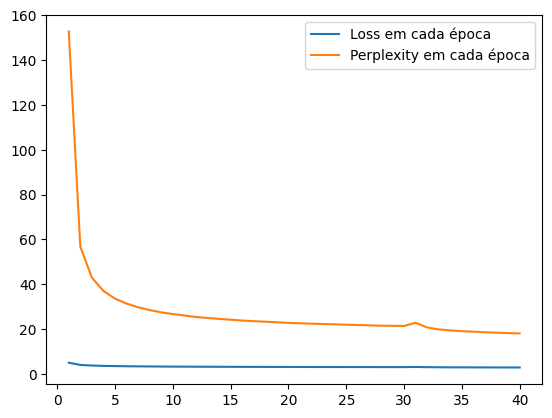

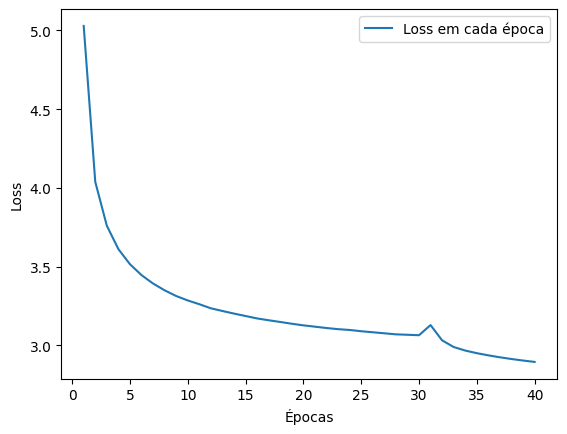

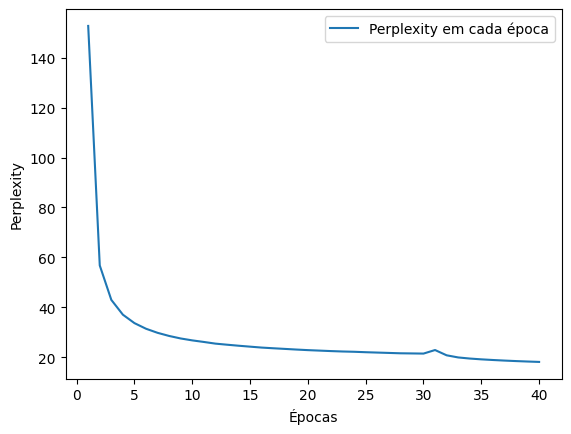

In [16]:
import matplotlib.pyplot as plt
lista_epochs = [i for i in range(1,epochs)]

# Plota cada lista com um rótulo (label)
plt.plot(lista_epochs, loss_training, label='Loss em cada época')
plt.plot(lista_epochs, perplexity_training, label='Perplexity em cada época')


# Adiciona título, legenda e exibe
plt.legend()
plt.show()

print("\n \n \n")

# Plota cada lista com um rótulo (label)
plt.plot(lista_epochs, loss_training, label='Loss em cada época')


# Adiciona título, legenda e exibe
plt.legend()
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.show()

print("\n \n \n")
# Plota cada lista com um rótulo (label)
plt.plot(lista_epochs, perplexity_training, label='Perplexity em cada época')


# Adiciona título, legenda e exibe
plt.legend()
plt.xlabel('Épocas')
plt.ylabel('Perplexity')
plt.show()


In [58]:
total_loss = 0.0
ac = 0.0
criterion = nn.CrossEntropyLoss()
batch_len = 0
with torch.no_grad():
    hidden_validation = None
    for batch in dataloader_validation:
        if hidden_validation is not None:
            hidden_validation = (hidden_validation[0].detach(), hidden_validation[1].detach())
        inputs = batch["input_ids"].to(device)
        targets = batch["labels"].to(device)

        outputs, hidden_validation = model_t_v(inputs, hidden_validation)
        target_reshaped = targets.reshape(-1)
        loss = criterion(outputs.reshape(-1, tokenizer.vocab_size), target_reshaped)
        total_loss += loss.item()
        predicted = outputs.argmax(dim=-1).reshape(-1)
        ac += ((predicted==target_reshaped).sum().item()) / target_reshaped.size(0)

mean_loss = total_loss / len(dataloader_validation)
print(f"Perda média na validação: {mean_loss}")

mean_loss_tensor = torch.tensor(mean_loss)

perplexity_validation = torch.exp(mean_loss_tensor)
print(f"Perplexidade na validação: {perplexity_validation.item()}")

perplexity_validation = torch.exp(mean_loss_tensor)
print(f"Acurácia na validação: {ac}")

Perda média na validação: 4.018192975417428
Perplexidade na validação: 55.60053253173828
Acurácia na validação: 7.8907503069721034


In [60]:
def make_prediction(model, dataloader_test, steps=0):
  inputs = generate_sample_input_predict(dataloader_test)
  hidden = None
  for _ in range(steps):
    with torch.no_grad():
      outputs, hidden = model(inputs.to(device), hidden)
      next_token_tensor = outputs[:, -1, :].argmax(-1,keepdim=True)
      inputs = torch.cat([inputs.to(device), next_token_tensor],dim=1)
  return inputs[0]



In [61]:
music_predicted = make_prediction(model_t_v, dataloader_test, steps=100)

In [62]:
music_decoded = tokenizer(music_predicted.squeeze().tolist())
print(music_decoded)

Score(ttype=Tick, tpq=8, begin=0, end=860, tracks=1, notes=298, time_sig=1, key_sig=0, markers=0)


In [68]:
midi = tokenizer(music_decoded)
print(midi)

TokSequence(tokens=['Bar_None', 'TimeSig_4/4', 'Position_0', 'Tempo_121.29', 'Position_24', 'Program_0', 'Pitch_78', 'Velocity_51', 'Duration_4.3.4', 'Position_30', 'Program_0', 'Pitch_47', 'Velocity_27', 'Duration_4.2.4', 'Program_0', 'Pitch_74', 'Velocity_39', 'Duration_3.6.8', 'Program_0', 'Pitch_68', 'Velocity_31', 'Duration_3.1.8', 'Bar_None', 'TimeSig_4/4', 'Position_4', 'Program_0', 'Pitch_62', 'Velocity_35', 'Duration_3.6.8', 'Program_0', 'Pitch_56', 'Velocity_39', 'Duration_3.5.8', 'Position_5', 'Program_0', 'Pitch_52', 'Velocity_35', 'Duration_3.5.8', 'Position_13', 'Program_0', 'Pitch_40', 'Velocity_35', 'Duration_2.4.8', 'Position_23', 'Program_0', 'Pitch_68', 'Velocity_47', 'Duration_1.2.8', 'Position_26', 'Program_0', 'Pitch_73', 'Velocity_55', 'Duration_1.0.8', 'Position_28', 'Program_0', 'Pitch_74', 'Velocity_55', 'Duration_0.5.8', 'Position_30', 'Program_0', 'Pitch_78', 'Velocity_71', 'Duration_0.3.8', 'Bar_None', 'TimeSig_4/4', 'Position_1', 'Program_0', 'Pitch_78', '

In [70]:
print(path_music)

/content/MIDI-LSTM-and-transformer-decoder/training/tokenizer_novo/9/music-9


In [74]:
import os
os.makedirs(complete_path, exist_ok=True)
music_to_midi = converte_output_to_midi(music_decoded, path_music)
print(music_decoded)

Score(ttype=Tick, tpq=8, begin=0, end=860, tracks=1, notes=298, time_sig=1, key_sig=0, markers=0)


In [75]:
tonal_estimator(f"{path_music}.mid")

A major
Tônica: A e modo: major
Consistência tonal: 0.9297744155012837
Melhor tonalidade: 1.599338162782992


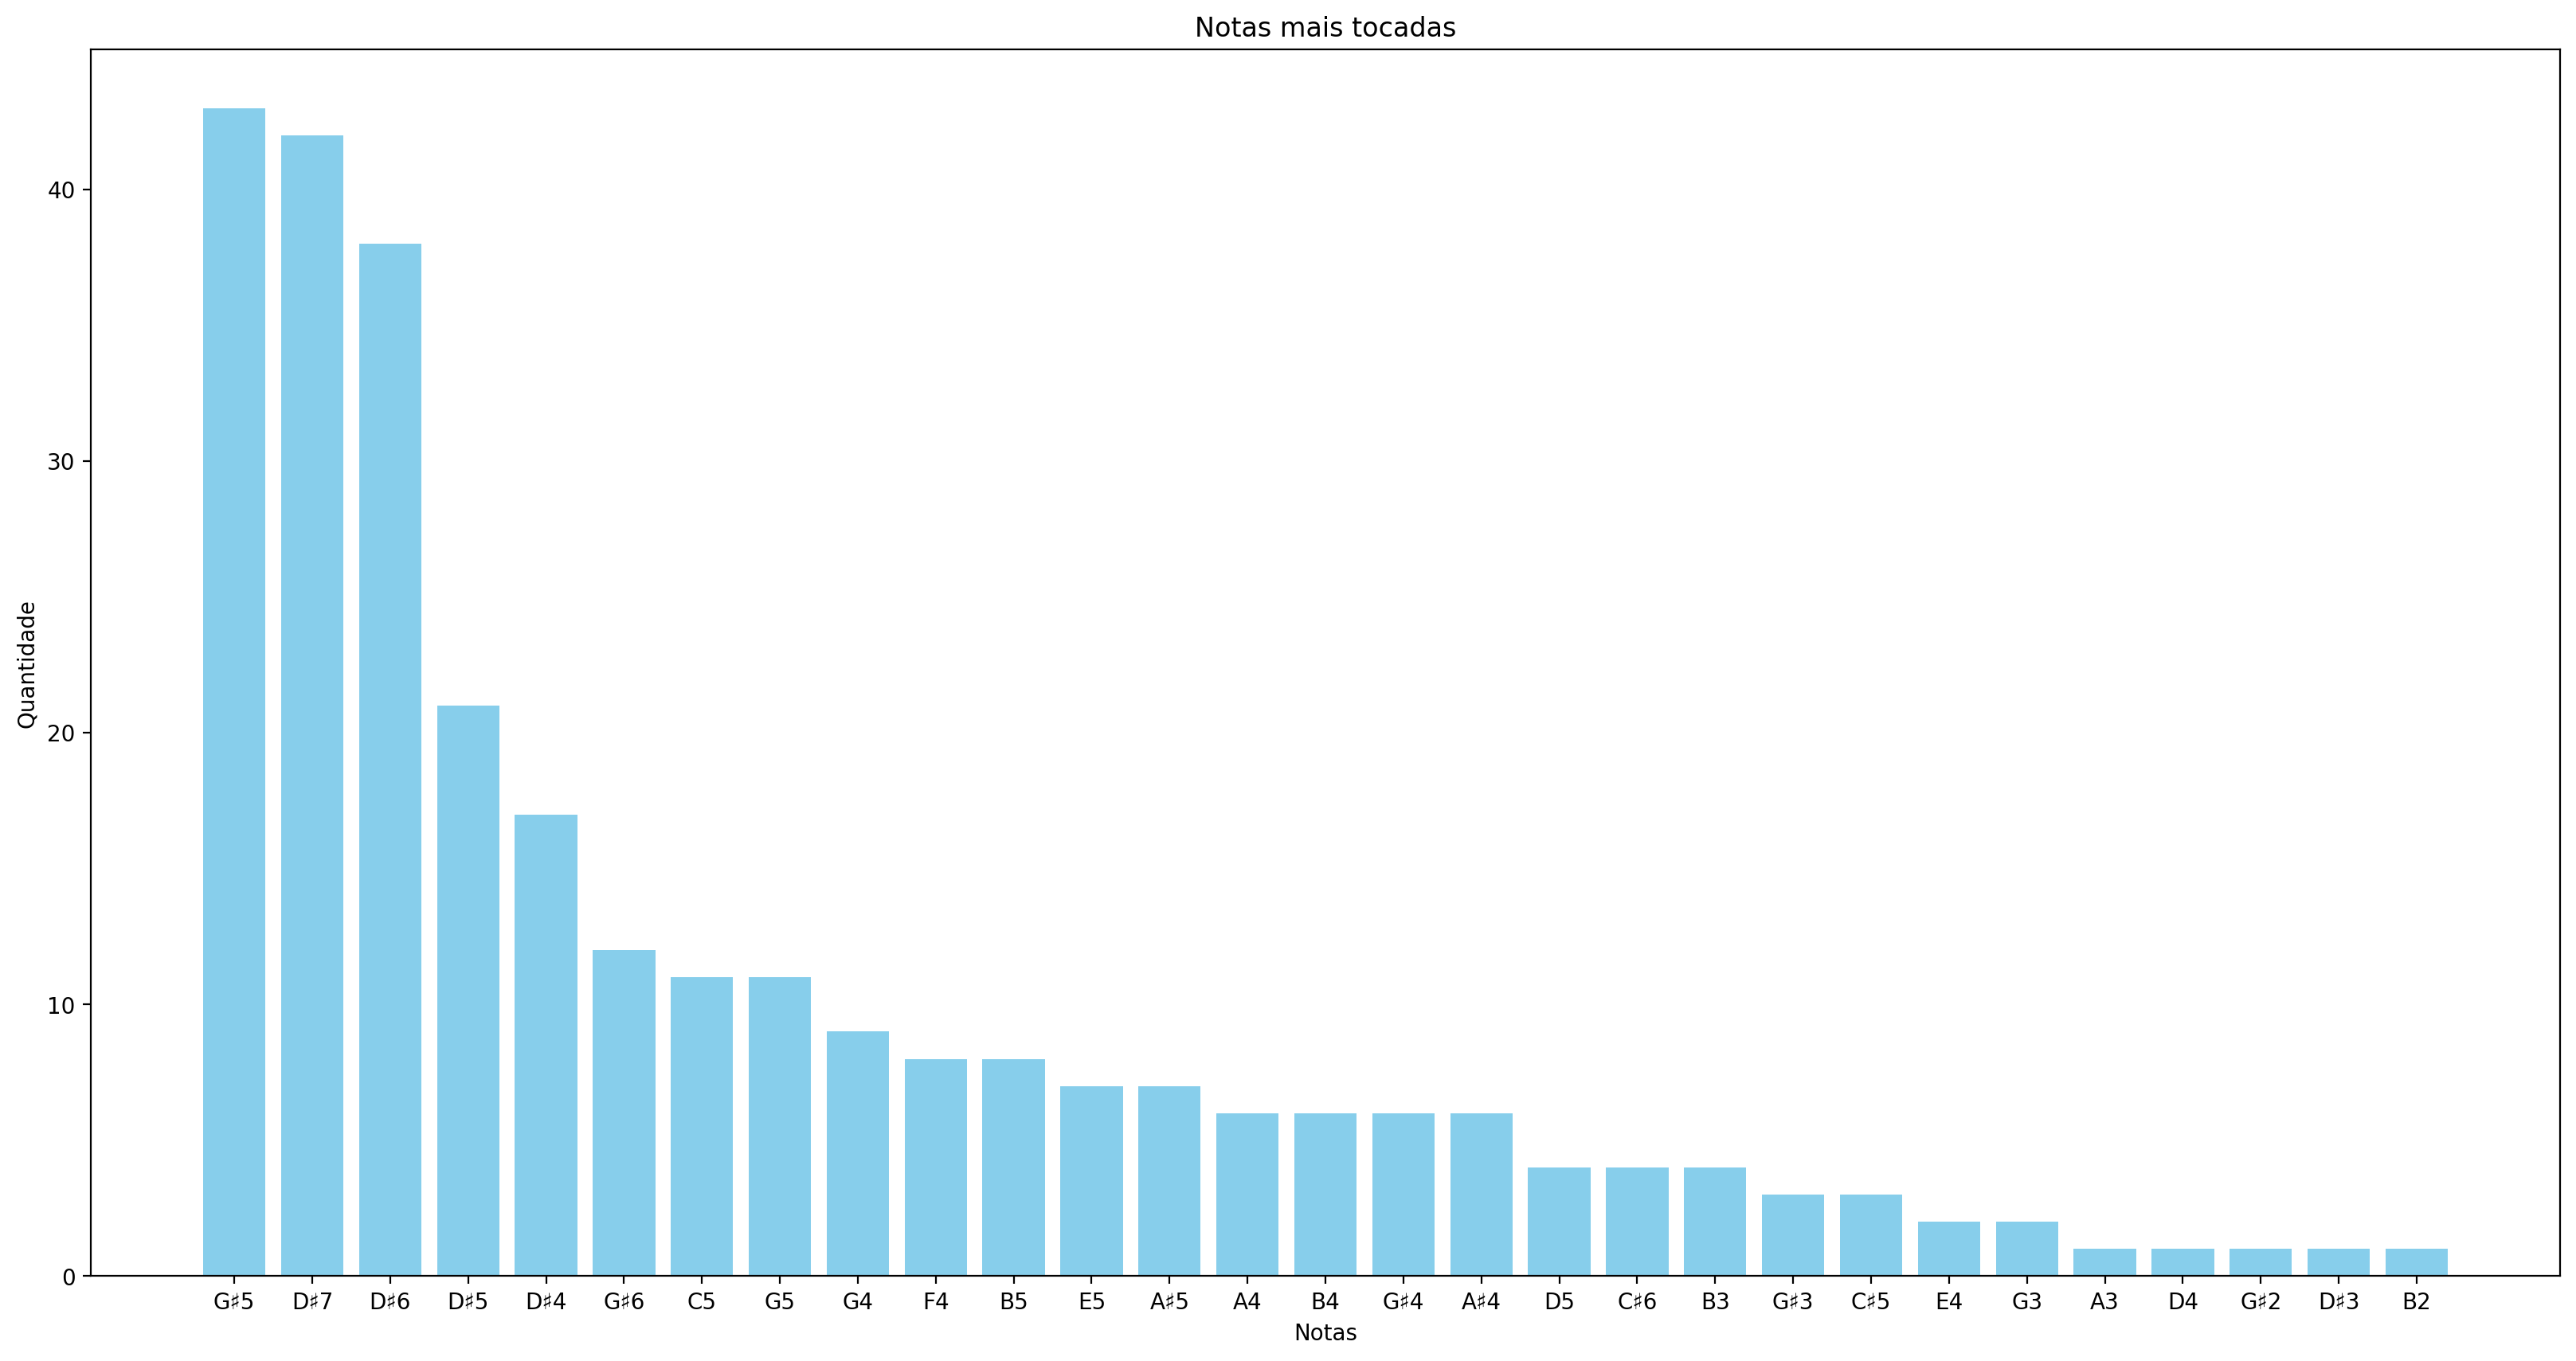

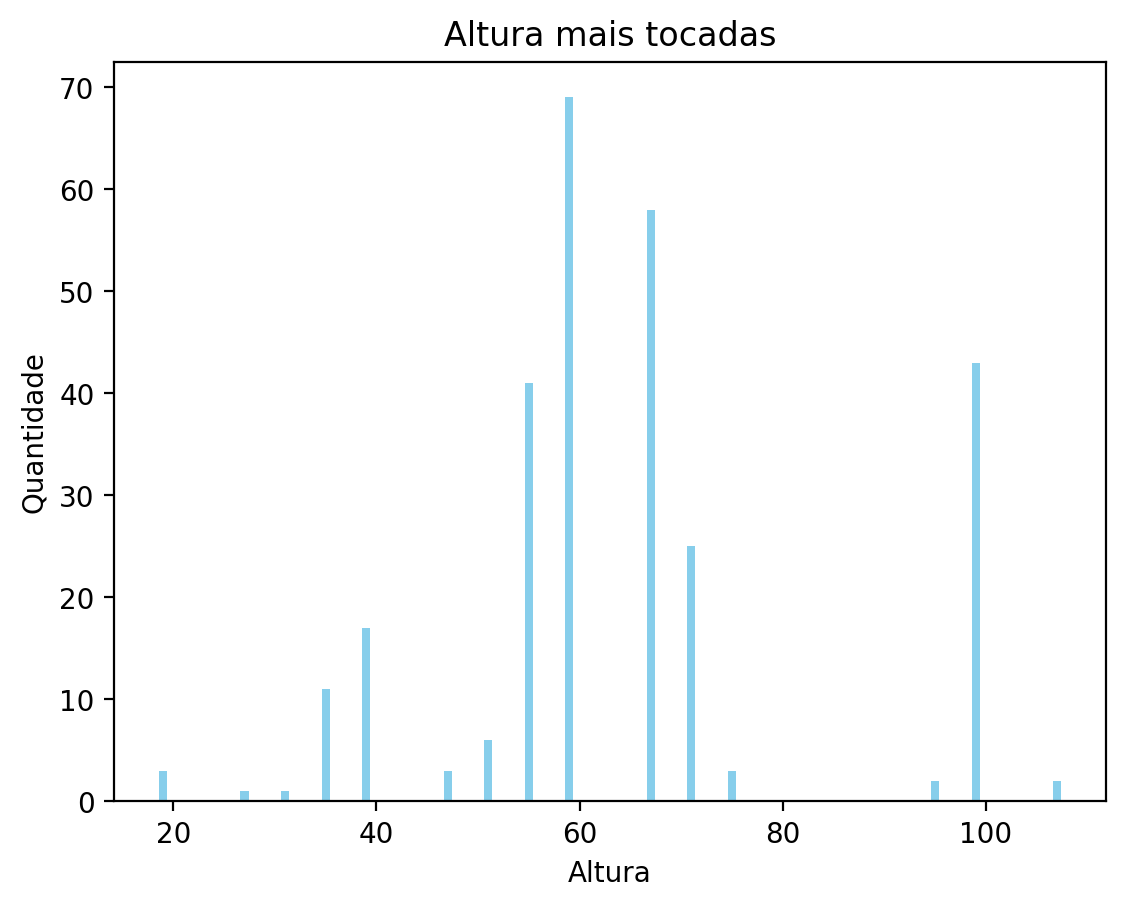


 
 

Quantidade compassos: 33


In [53]:
counter_notes(midi.tokens)